# Recovery against the horizon

Sample paths of the ARI against $n$, at fixed $N$ — the published Figure 4, with the outer
level of randomness the design was missing.

That figure drew the kernels once and replicated the data 50 times, so everything it showed
was a property of one draw of a $K = 4$ mixture at $\alpha = 0.3$. The rise from 0.67 to 1
it reported may or may not be typical; nothing in the experiment separated the mixture from
the draw. Here several mixtures are drawn, each held fixed while its datasets are
replicated, so the figure carries both: the spread between replicates of one mixture, and
the spread between mixtures.

Everything else is unchanged. A replicate is a genuine sample path — the same $N$ sequences
read at growing lengths, through the nested prefixes of `om_matrices` — so the thin lines
show the variability of a single experiment, not an interval around the mean. The three
estimators share these axes exactly, so the figures stack and compare.

Exact recovery is the event $\mathrm{ARI} = 1$ and is read off the top of the plot; its
probability is tabulated under each figure.

In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from clustering import adjusted_rand_index, exact_recovery, labels_at_k
from experiments import (ResultsWriter, draw_markov_mixture,
                         estimate_gamma_paths, eta_rows, save_mixture, stream,
                         univariate_om, wilson_interval)
from figures import PAPER_STYLE

## Setup

Everything reported below is produced by the sweep in this notebook. With
`SOURCE = "compute"`, every run starts fresh, overwrites its dedicated tables, and never
reads rows from an earlier run. `SOURCE = "paper"` is the explicit opt-out that loads the
archived tables. The default computation takes about twenty minutes at $N = 200$, and
roughly sixteen times that at the published $N = 800$.

In [ ]:
# --- the knobs -------------------------------------------------------------
SOURCE = "compute"       # "compute": rebuild everything; "paper": archived CSVs
ALPHA_FIX = 1
K_FIX = 4
PATH_N = 400               # use 800 for the published setting
N_MIX = 1
N_DATA = 20
HORIZONS = np.arange(50, 500, 50, dtype=int)
N_GAMMA = 60               # independent pairs per entry of Gamma^(n)
LEVEL = 0.95
D_STATES = 5
COST = "constant"
SEED = 20260901
PAM_RESTARTS = 1
PATH_ALGOS = ("single", "average", "pam")

RESULTS = Path("results")
FIGURES = Path("Figures/Recovery")
FIGURES.mkdir(parents=True, exist_ok=True)
OUT_PATH = RESULTS / "recovery_path_notebook_cluster.csv"
OUT_ETA = RESULTS / "recovery_path_notebook_eta.csv"
PAPER_PATH = RESULTS / "path_cluster_main.csv"
PAPER_ETA = RESULTS / "path_eta_main.csv"

PATH_FIELDS = ["alpha", "K", "d", "mixture_id", "dataset_id", "n", "N",
               "cost_scheme", "algorithm", "exact_recovery", "ari",
               "mixture_key"]
ETA_FIELDS = ["alpha", "K", "mixture_id", "n", "cost_scheme", "eta_hat",
              "eta_ci_low", "eta_ci_high", "separation_status", "n_pairs",
              "level", "mixture_key"]

om = univariate_om(COST, D_STATES, rng=stream(SEED, "cost", COST))
assumption = om.assumption_1()
metric_ok = all(v for k, v in assumption.items() if k.startswith("("))
print(f"cost scheme {om.name}: Assumption 1 holds = {metric_ok}, M = {om.M:.3f}")


def score_recovery_paths(mixture, matrices, truth, dataset_id, rng):
    """Only what this notebook plots: one partition per algorithm at known K."""
    rows = []
    for g, n in enumerate(HORIZONS):
        D = matrices[g]
        for algorithm in PATH_ALGOS:
            labels = labels_at_k(D, K_FIX, algorithm, rng=rng,
                                 pam_restarts=PAM_RESTARTS)
            rows.append({"alpha": ALPHA_FIX, "K": K_FIX, "d": mixture.d,
                         "mixture_id": mixture.mixture_id,
                         "dataset_id": dataset_id, "n": int(n), "N": PATH_N,
                         "cost_scheme": om.name, "algorithm": algorithm,
                         "exact_recovery": int(exact_recovery(labels, truth)),
                         "ari": adjusted_rand_index(labels, truth),
                         "mixture_key": mixture.key})
    return rows


def compute_paths():
    """Draw mixtures, estimate their geometry independently, and score all paths."""
    OUT_PATH.unlink(missing_ok=True)
    OUT_ETA.unlink(missing_ok=True)
    path_writer = ResultsWriter(OUT_PATH, PATH_FIELDS)
    eta_writer = ResultsWriter(OUT_ETA, ETA_FIELDS)
    start = time.perf_counter()
    try:
        for m in range(N_MIX):
            mixture = draw_markov_mixture(K_FIX, D_STATES, ALPHA_FIX, m, SEED)
            save_mixture(mixture, RESULTS / "mixtures" / "recovery-path")
            estimate = estimate_gamma_paths(
                mixture, om, HORIZONS, N_GAMMA,
                stream(SEED, "path-gamma", ALPHA_FIX, K_FIX, m))
            geometry = eta_rows(mixture, om, estimate, level=LEVEL)
            eta_writer.write([{k: row.get(k, "") for k in ETA_FIELDS}
                              for row in geometry])
            for r in range(N_DATA):
                rng = stream(SEED, "path-data", ALPHA_FIX, K_FIX, m, r)
                X, truth = mixture.sample_dataset(PATH_N, int(HORIZONS[-1]), rng)
                matrices = om.matrices(X, HORIZONS)
                rows = score_recovery_paths(mixture, matrices, truth, r, rng)
                path_writer.write([{k: row.get(k, "") for k in PATH_FIELDS}
                                   for row in rows])
            elapsed = time.perf_counter() - start
            left = (N_MIX - m - 1) * elapsed / (m + 1)
            print(f"mixture {m + 1}/{N_MIX}, ~{left/60:.1f} min left", flush=True)
    finally:
        path_writer.close()
        eta_writer.close()


if SOURCE == "compute":
    compute_paths()

path = pd.read_csv(OUT_PATH if SOURCE == "compute" else PAPER_PATH)
eta = pd.read_csv(OUT_ETA if SOURCE == "compute" else PAPER_ETA)
print(f"alpha = {ALPHA_FIX}, K = {K_FIX}, N = {PATH_N}; "
      f"{N_MIX} mixtures x {N_DATA} datasets over horizons {list(HORIZONS)}")

cost scheme constant: Assumption 1 holds = True, M = 2.000


## The figure

Same layout as `plot_gamma_convergence` in `om_convergence.ipynb`: one thin line per
replicate, the mean over them on top. The six intermediate lines are the per-mixture means —
the level the published figure could not show, since it had a single mixture. Where they
fan out, the horizon needed for recovery depends on which kernels were drawn; where they
collapse onto the mean, it does not.

In [ ]:
COL = {"single":  "#1b6ca8",       # the blue of om_convergence.ipynb
       "average": "#6a51a3",       # a third hue, so no two estimators share a colour
       "pam":     "#c0392b"}
NAMES = {"single": "single linkage", "average": "average linkage", "pam": "PAM"}


def curves(df, algorithm, value="ari"):
    """(replicate, horizon) array, plus the per-mixture means."""
    sub = df[df.algorithm == algorithm]
    wide = sub.pivot_table(index=["mixture_id", "dataset_id"], columns="n", values=value)
    wide = wide.reindex(columns=HORIZONS)
    per_mixture = sub.pivot_table(index="mixture_id", columns="n", values=value)
    return wide.to_numpy(), per_mixture.reindex(columns=HORIZONS).to_numpy()


def plot_ari_curve(algorithm, filename=None):
    reps, per_mixture = curves(path, algorithm)
    colour = COL[algorithm]
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        ax.plot(HORIZONS, reps.T, color=colour, lw=0.6, alpha=0.13)
        ax.plot(HORIZONS, per_mixture.T, color=colour, lw=0.9, alpha=0.5)
        ax.plot(HORIZONS, reps.mean(0), color=colour, lw=1.9,
                label=rf"mean over {reps.shape[0]} replicates")
        ax.plot([], [], color=colour, lw=0.9, alpha=0.5,
                label=rf"{per_mixture.shape[0]} mixture means")
        ax.set_xlabel(r"$n$, length of a sequence")
        ax.set_ylabel(f"ARI, {NAMES[algorithm]}")
        ax.set_ylim(-0.04, 1.04)
        ax.axhline(0.5, color="0.6", lw=0.7, ls=(0, (1, 3)), zorder=0)
        ax.set_title(rf"{NAMES[algorithm]} --- $N = {PATH_N}$, $K = {K_FIX}$, "
                     rf"$\alpha = {ALPHA_FIX}$", fontsize=10)
        ax.legend(loc="lower right", handlelength=2.6, borderaxespad=0.6)
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(FIGURES / f"{filename}.{ext}", bbox_inches="tight")
            print("figure written to", FIGURES / f"{filename}.pdf")
        plt.show()
    return fig


def exact_recovery_table(algorithm):
    """P(ARI = 1) at each horizon, with its Wilson interval."""
    sub = path[path.algorithm == algorithm]
    rows = []
    for n in HORIZONS:
        s = sub[sub.n == n].exact_recovery
        lo, hi = wilson_interval(int(s.sum()), len(s))
        rows.append({"n": int(n), "P(exact)": f"{s.mean():.2f}",
                     "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                     "mean ARI": f"{sub[sub.n == n].ari.mean():.3f}"})
    return pd.DataFrame(rows)

### Average linkage

figure written to Figures\Recovery\ari_path_average_linkage.pdf


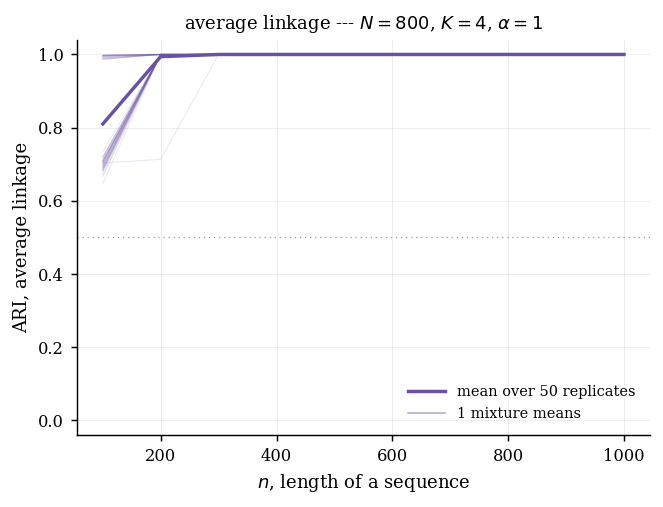

   n P(exact)       95% CI mean ARI
 100     0.04 [0.01, 0.13]    0.810
 200     0.94 [0.84, 0.98]    0.994
 300     1.00 [0.93, 1.00]    1.000
 400     1.00 [0.93, 1.00]    1.000
 500     1.00 [0.93, 1.00]    1.000
 600     1.00 [0.93, 1.00]    1.000
 700     1.00 [0.93, 1.00]    1.000
 800     1.00 [0.93, 1.00]    1.000
 900     1.00 [0.93, 1.00]    1.000
1000     1.00 [0.93, 1.00]    1.000


In [ ]:
_ = plot_ari_curve("average", filename="ari_path_average_linkage")
print(exact_recovery_table("average").to_string(index=False))

### PAM

figure written to Figures\Recovery\ari_path_pam.pdf


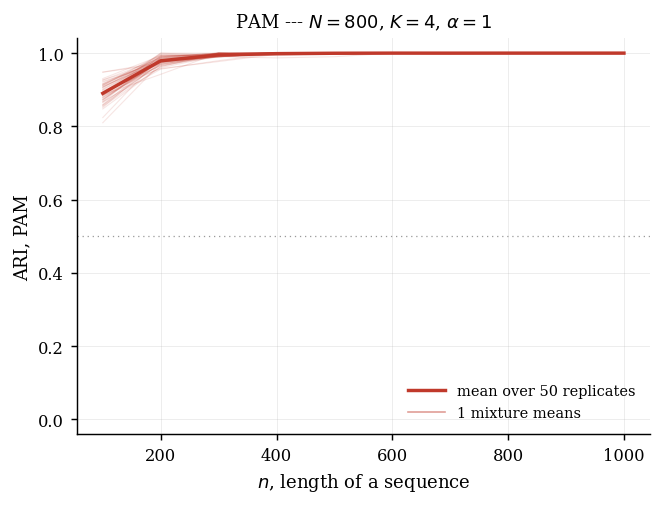

   n P(exact)       95% CI mean ARI
 100     0.00 [0.00, 0.07]    0.890
 200     0.04 [0.01, 0.13]    0.979
 300     0.28 [0.17, 0.42]    0.995
 400     0.68 [0.54, 0.79]    0.999
 500     0.94 [0.84, 0.98]    1.000
 600     1.00 [0.93, 1.00]    1.000
 700     0.98 [0.90, 1.00]    1.000
 800     1.00 [0.93, 1.00]    1.000
 900     1.00 [0.93, 1.00]    1.000
1000     1.00 [0.93, 1.00]    1.000


In [ ]:
_ = plot_ari_curve("pam", filename="ari_path_pam")
print(exact_recovery_table("pam").to_string(index=False))

## What the mixtures do

The per-mixture means above fan out; the table says by how much. A horizon at which one
mixture is recovered every time can leave another below a half, which is the reason for
drawing more than one.

$\eta_n$ is estimated on an independent sample at the same horizons, so the ordering of the
mixtures can be read against the geometry rather than against their labels.

In [ ]:
rows = []
for m in sorted(path.mixture_id.unique()):
    row = {"mixture": m}
    e = eta[eta.mixture_id == m]
    row["eta at n=%d" % HORIZONS[-1]] = f"{e[e.n == HORIZONS[-1]].eta_hat.iloc[0]:+.3f}"
    row["verdict"] = e[e.n == HORIZONS[-1]].separation_status.iloc[0]
    for algo in ("average", "pam"):
        s = path[(path.mixture_id == m) & (path.algorithm == algo)
                 & (path.n == HORIZONS[-1])]
        row[f"{algo}: P(exact)"] = f"{s.exact_recovery.mean():.2f}"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

 mixture eta at n=1000   verdict average: P(exact) pam: P(exact)
       0        +0.069 separated              1.00          1.00


## Appendix: single linkage

The estimator Theorem 3.5 is about, on the same axes, where the published Figure 9 had it.

figure written to Figures\Recovery\ari_path_single_linkage.pdf


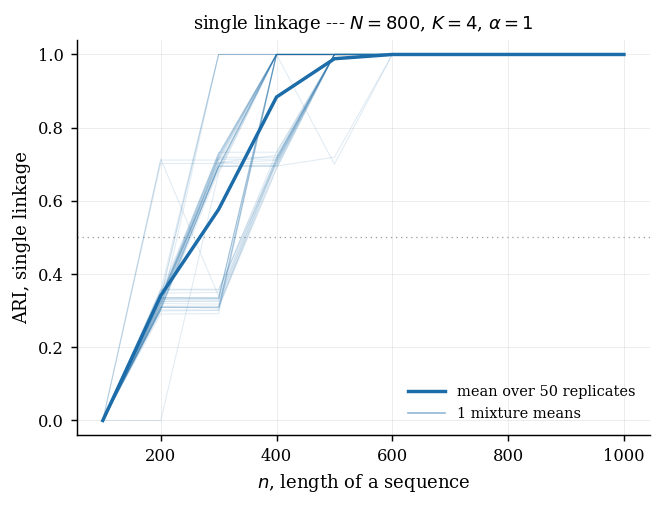

   n P(exact)       95% CI mean ARI
 100     0.00 [0.00, 0.07]    0.000
 200     0.00 [0.00, 0.07]    0.341
 300     0.08 [0.03, 0.19]    0.577
 400     0.60 [0.46, 0.72]    0.884
 500     0.96 [0.87, 0.99]    0.988
 600     1.00 [0.93, 1.00]    1.000
 700     1.00 [0.93, 1.00]    1.000
 800     1.00 [0.93, 1.00]    1.000
 900     1.00 [0.93, 1.00]    1.000
1000     1.00 [0.93, 1.00]    1.000

PAM certified one-swap stationary in 500/500 runs; hit the swap cap 0 times


In [ ]:
_ = plot_ari_curve("single", filename="ari_path_single_linkage")
print(exact_recovery_table("single").to_string(index=False))